# Power, HR, BG Relationship Analysis

Single activity first, pooled activities second, with one plot per code cell.

Import reusable utilities and scientific libraries used across the workflow.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('.')

from utilities.training_glucose_utils import (
    AnalysisConfig,
    list_activities,
    choose_activity,
    run_activity_analysis,
    run_single_activity_gam,
    run_pooled_gam,
    plot_hr_bg_scatter,
    plot_power_bg_scatter,
    plot_lag_correlation,
    plot_delay_adjusted_overlay,
    plot_gam_surface_and_fit,
    compute_best_bg_by_hr_bin,
    plot_best_bg_by_hr_bin,
)

pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')


Set API/config parameters and analysis defaults (binning and sample thresholds).

In [23]:

cfg = AnalysisConfig(
    intervals_base_url=os.getenv('INTERVALS_BASE_URL', 'https://intervals.icu'),
    intervals_api_key=os.getenv('INTERVALS_API_KEY', ''),
    intervals_athlete_id=os.getenv('INTERVALS_ATHLETE_ID', '0'),
    intervals_streams_base_url=os.getenv('INTERVALS_STREAMS_BASE_URL', ''),
    nightscout_base_url=os.getenv('NIGHTSCOUT_BASE_URL', '').rstrip('/'),
    nightscout_token=os.getenv('NIGHTSCOUT_TOKEN', ''),
    nightscout_api_secret=os.getenv('NIGHTSCOUT_API_SECRET', ''),
    pre_activity_hours=int(os.getenv('PRE_ACTIVITY_HOURS', '2')),
    post_activity_hours=int(os.getenv('POST_ACTIVITY_HOURS', '6')),
    merge_tolerance=os.getenv('MERGE_TOLERANCE', '3min'),
)

BIN_SIZE = '5min'
MIN_SAMPLES = 10

if not cfg.intervals_api_key:
    raise ValueError('Set INTERVALS_API_KEY')
if not cfg.nightscout_base_url:
    raise ValueError('Set NIGHTSCOUT_BASE_URL')

cfg


AnalysisConfig(intervals_base_url='https://intervals.icu', intervals_api_key='59inwnqxsjucv0pp5gnbwunh', intervals_athlete_id='i298161', intervals_streams_base_url='', nightscout_base_url='https://p01--nightscout--jfv4bxh9hrff.code.run', nightscout_token='', nightscout_api_secret='', pre_activity_hours=2, post_activity_hours=6, merge_tolerance='3min')

fetch recent activities to choose one target session for detailed analysis.

In [6]:
activities_df = list_activities(cfg, days_back=120).reset_index(drop=True)
cols = [c for c in ['start_date_local', 'type', 'name', 'distance', 'moving_time', 'elapsed_time'] if c in activities_df.columns]
activities_df[cols].head(30)


,start_date_local,type,name,distance,moving_time,elapsed_time
0,2026-04-07 14:24:44,Ride,Berlin Cycling,23253.10,4380,5045
1,2026-04-07 10:05:36,Ride,Berlin Cycling,13584.95,2561,3053
2,2026-04-06 16:13:41,Ride,Berlin Road Cycling,63296.95,8831,9230
3,2026-04-04 16:54:39,Ride,Berlin Road Cycling,51336.99,7274,8334
4,2026-04-04 02:30:00,Ride,Berlin Cycling,6809.18,1516,1628
5,2026-04-03 21:22:10,Ride,Berlin Cycling,8339.90,1751,3961
6,2026-04-03 17:44:11,Ride,Berlin Road Cycling,43373.89,6309,6659
7,2026-04-02 23:18:23,Ride,Berlin Cycling,7765.73,1529,1713
8,2026-04-02 18:49:48,Ride,Berlin Cycling,9614.33,1731,2041
9,2026-04-02 12:32:41,Ride,Berlin Road Cycling,41423.11,5835,6596


Short explanation: select the activity index that will be used for the single-activity phase.

In [8]:
SELECTED_ACTIVITY_INDEX = 2
selected_activity = choose_activity(activities_df, SELECTED_ACTIVITY_INDEX)
selected_activity


{'id': 'i137657200',
 'start_date_local': Timestamp('2026-04-06 16:13:41'),
 'type': 'Ride',
 'name': 'Berlin Road Cycling',
 'distance': 63296.95,
 'moving_time': 8831,
 'elapsed_time': 9230,
 'icu_ignore_time': False,
 'icu_pm_cp': 172.0,
 'icu_pm_w_prime': 14577.0,
 'icu_pm_p_max': 849.0,
 'icu_pm_ftp': 176.0,
 'icu_pm_ftp_secs': 2520.0,
 'icu_pm_ftp_watts': 177.0,
 'icu_ignore_power': False,
 'icu_rolling_cp': None,
 'icu_rolling_w_prime': 20215.613,
 'icu_rolling_p_max': 1097.6025,
 'icu_rolling_ftp': 246.0,
 'icu_rolling_ftp_delta': 0.0,
 'icu_training_load': 118,
 'icu_atl': 83.93094,
 'icu_ctl': 78.38817,
 'ss_p_max': 0.48358727,
 'ss_w_prime': 1.2562788,
 'ss_cp': 150.08029,
 'paired_event_id': None,
 'icu_ftp': 249.0,
 'icu_joules': 1451269.0,
 'icu_recording_time': 8950,
 'icu_weighted_avg_watts': 173.0,
 'carbs_used': 334.0,
 'description': None,
 'start_date': '2026-04-06T14:13:41Z',
 'icu_distance': 63296.95,
 'coasting_time': 521.0,
 'total_elevation_gain': 228.0,
 'tota

run the core pipeline (alignment, binning, lag scan) for the selected activity.

In [10]:
single_result = run_activity_analysis(
    cfg=cfg,
    activity=selected_activity,
    bin_size=BIN_SIZE,
    hi_quantile=0.85,
    requested_streams='time,heartrate,power',
)

single_df = single_result['aligned_df']
print('Activity ID:', single_result['activity_id'])
print('Binned samples:', len(single_df))
print('Available stream keys:', single_result['stream_keys'])


Activity ID: i137657200
Binned samples: 28
Available stream keys: ['altitude', 'bloodglucose', 'cadence', 'distance', 'heartrate', 'latlng', 'left_pedal_smoothness', 'left_torque_effectiveness', 'temp', 'time', 'torque', 'velocity_smooth', 'watts']


Short explanation: compute nonparametric and linear correlations among power, HR, and BG for this activity.

In [11]:
def _safe_corr(a, b, method='pearson'):
    pair = pd.concat([a, b], axis=1).dropna()
    if len(pair) < 3:
        return np.nan
    if pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return pair.iloc[:, 0].corr(pair.iloc[:, 1], method=method)

single_relationship_summary = pd.Series({
    'samples': int(len(single_df.dropna(subset=['power', 'hr', 'bg']))),
    'pearson_power_bg': _safe_corr(single_df['power'], single_df['bg'], method='pearson'),
    'spearman_power_bg': _safe_corr(single_df['power'], single_df['bg'], method='spearman'),
    'pearson_power_hr': _safe_corr(single_df['power'], single_df['hr'], method='pearson'),
    'spearman_power_hr': _safe_corr(single_df['power'], single_df['hr'], method='spearman'),
    'pearson_hr_bg': _safe_corr(single_df['hr'], single_df['bg'], method='pearson'),
    'spearman_hr_bg': _safe_corr(single_df['hr'], single_df['bg'], method='spearman'),
})
single_relationship_summary


samples              28.000000
pearson_power_bg      0.260154
spearman_power_bg     0.018610
pearson_power_hr      0.820287
spearman_power_hr     0.663383
pearson_hr_bg         0.563606
spearman_hr_bg        0.320197
dtype: float64

 plot HR vs BG scatter to inspect direct coupling between cardiovascular response and glucose.

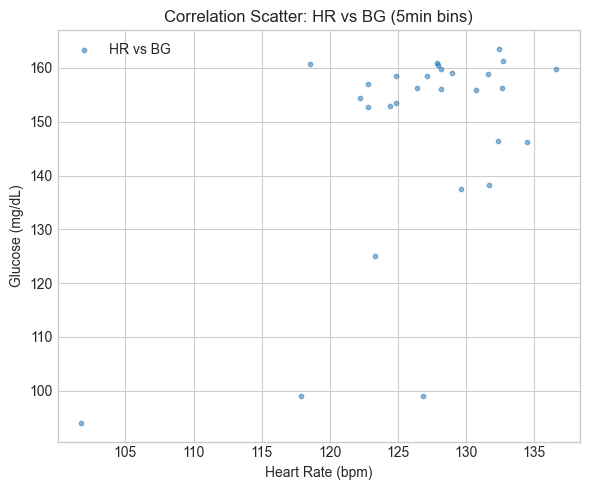

In [12]:
plot_hr_bg_scatter(single_df, bin_size=BIN_SIZE)


plot Power vs BG scatter to inspect glucose dependence of external work output.

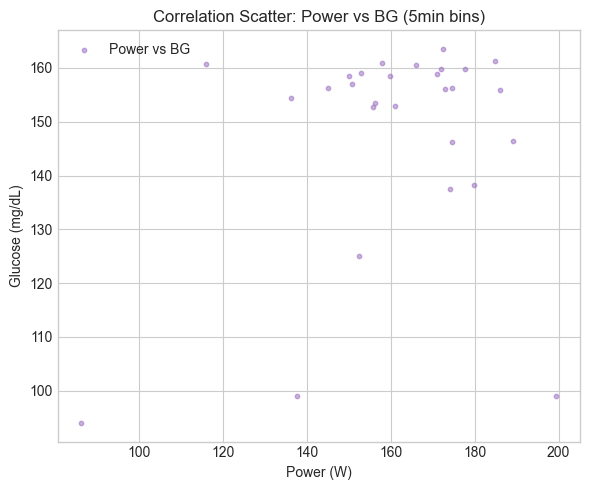

In [13]:
plot_power_bg_scatter(single_df, bin_size=BIN_SIZE)


plot HR-BG lag correlation curve to identify the dominant delay relationship.

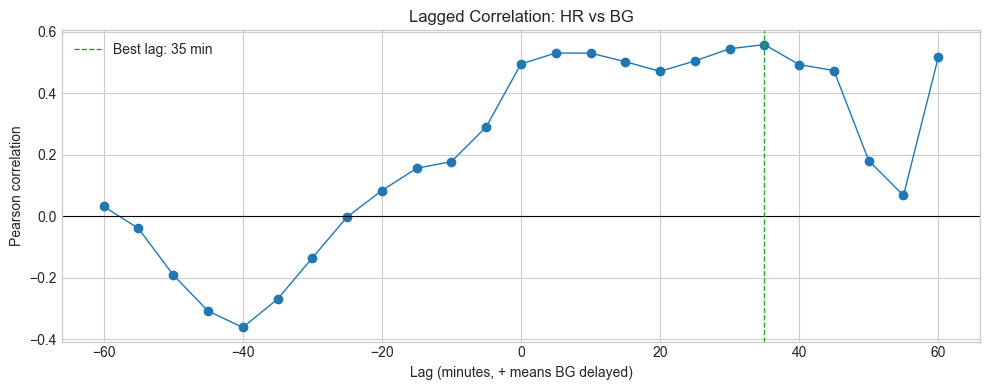

In [14]:
plot_lag_correlation(single_result['lag_corr_df'])


 overlay normalized HR, Power, and delay-adjusted BG in time to compare dynamics.

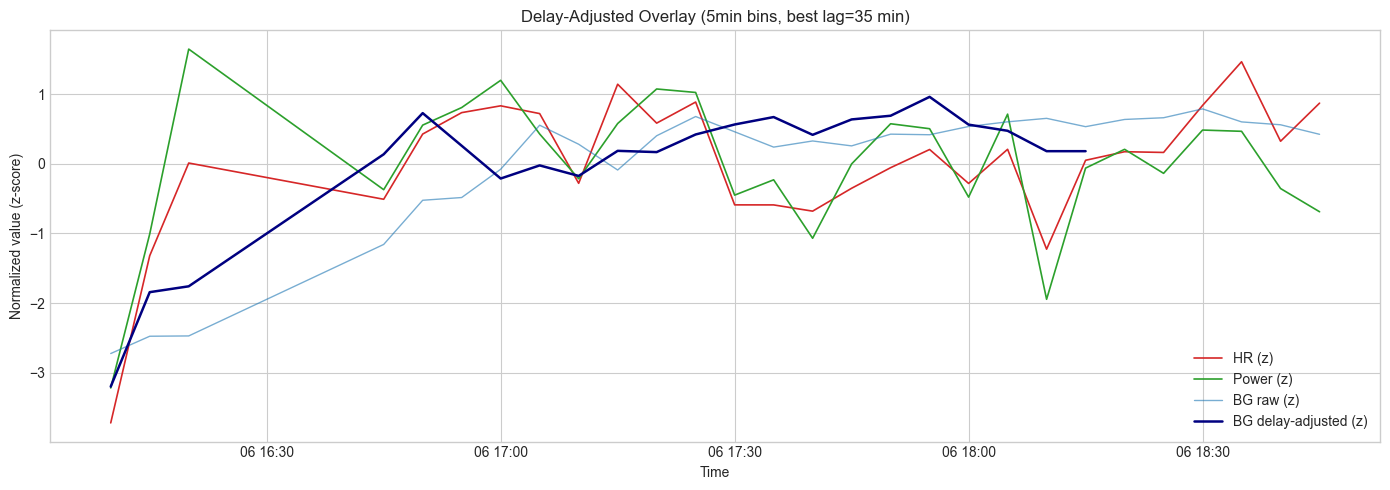

In [15]:
single_overlay_df = plot_delay_adjusted_overlay(single_df, single_result['lag_corr_df'], bin_size=BIN_SIZE)


fit a single-activity GAM and report sample count, inferred lag, and goodness-of-fit.

In [16]:
single_gam = run_single_activity_gam(single_result, bin_size=BIN_SIZE, min_samples=MIN_SAMPLES)

if single_gam is None:
    print('Not enough samples for single-activity power GAM.')
else:
    print('Single GAM samples:', single_gam['samples'])
    print('Single GAM best lag (BG shift):', single_gam['best_lag'], 'min')
    print('Single GAM R^2:', round(single_gam['r2'], 3))


Single GAM samples: 22
Single GAM best lag (BG shift): 35 min
Single GAM R^2: 0.103


 visualize the single-activity GAM surface and observed-vs-predicted fit.

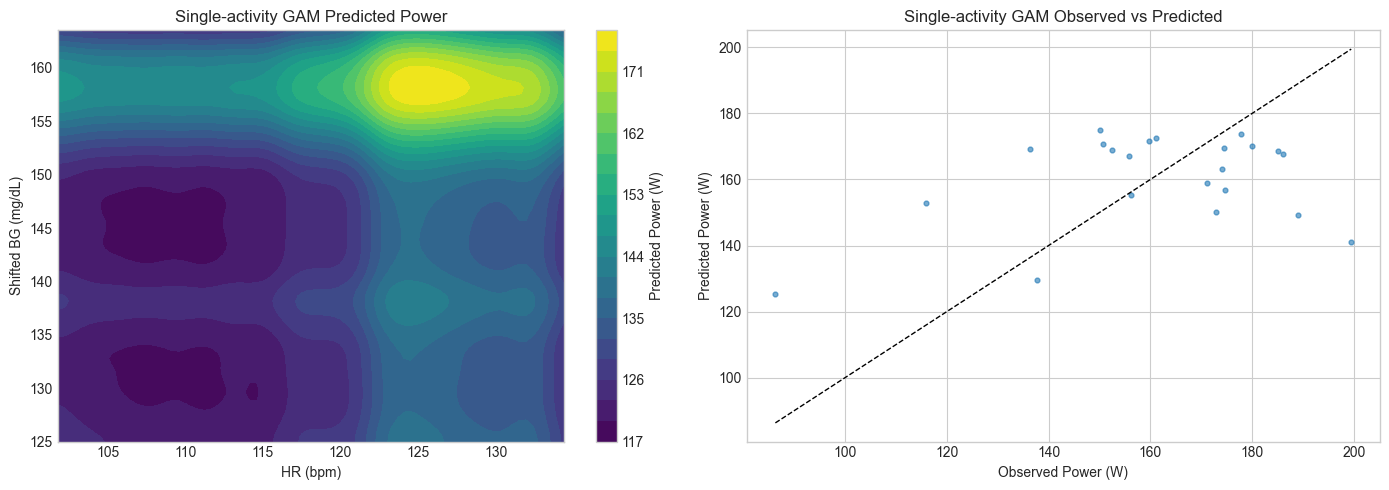

In [18]:
if single_gam is not None:
    plot_gam_surface_and_fit(
        single_gam['gam_df'],
        single_gam['y_hat'],
        title_prefix='Single-activity GAM',
        gam_model=single_gam.get('gam_model'),
    )
else:
    print('Single-activity GAM plot skipped.')


Build pooled GAM dataset across recent activities and summarize pooled correlations.

In [25]:
pooled_gam = run_pooled_gam(
    cfg=cfg,
    activities_df=activities_df,
    bin_size=BIN_SIZE,
    max_activities=200,
    min_samples_per_activity=MIN_SAMPLES,
)

if pooled_gam is None:
    print('No eligible pooled dataset for GAM.')
else:
    pooled_gam_df = pooled_gam['pooled_gam_df']
    print('Eligible activities:', len(pooled_gam['used_activities']))
    print('Pooled samples:', pooled_gam['samples'])
    print('Pooled GAM R^2:', round(pooled_gam['r2'], 3))

    pooled_summary = pd.Series({
        'samples': int(len(pooled_gam_df.dropna(subset=['power', 'hr', 'bg_shifted']))),
        'pearson_power_bg_shifted': _safe_corr(pooled_gam_df['power'], pooled_gam_df['bg_shifted'], method='pearson'),
        'spearman_power_bg_shifted': _safe_corr(pooled_gam_df['power'], pooled_gam_df['bg_shifted'], method='spearman'),
        'pearson_power_hr': _safe_corr(pooled_gam_df['power'], pooled_gam_df['hr'], method='pearson'),
        'spearman_power_hr': _safe_corr(pooled_gam_df['power'], pooled_gam_df['hr'], method='spearman'),
    })
    pooled_summary


Eligible activities: 37
Pooled samples: 1202
Pooled GAM R^2: 0.47


Visualize the pooled GAM surface to inspect global power-HR-BG structure.

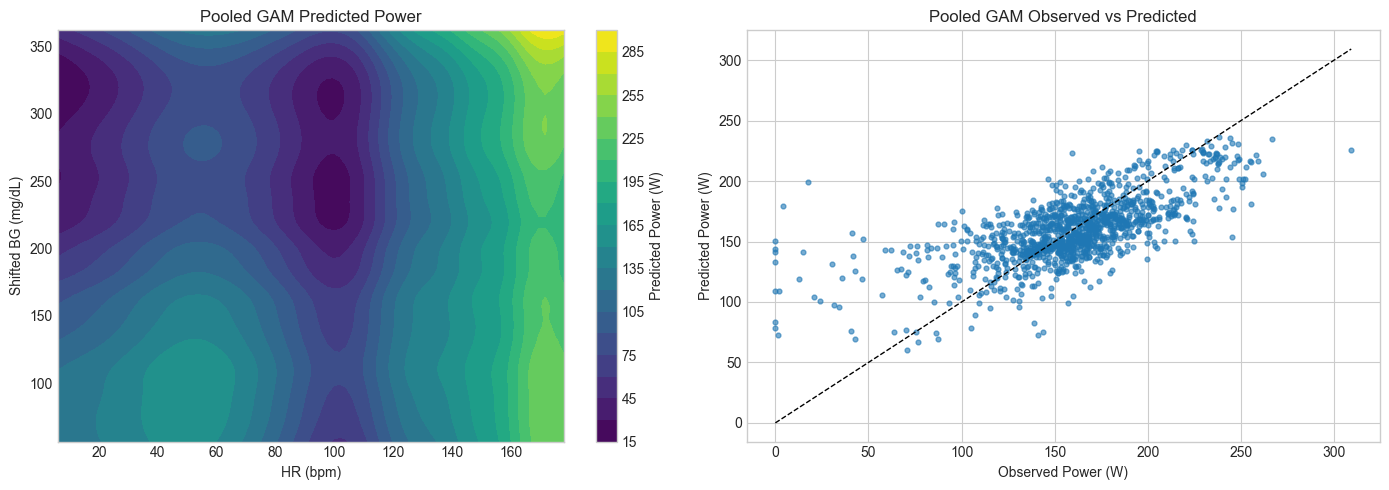

In [26]:
if pooled_gam is not None:
    plot_gam_surface_and_fit(
        pooled_gam_df,
        pooled_gam['y_hat'],
        title_prefix='Pooled GAM',
        gam_model=pooled_gam.get('gam_model'),
    )
else:
    print('Pooled GAM plot skipped.')


Compute BG targets that maximize efficiency (power/HR) within 5-bpm HR bins.

In [27]:
eff_source_df = pooled_gam_df.copy() if 'pooled_gam_df' in globals() else pd.DataFrame()
source_label = 'Pooled Activities'

if eff_source_df.empty:
    print('No dataset available for efficiency-target analysis.')
else:
    best_bg_by_bin = compute_best_bg_by_hr_bin(eff_source_df, hr_bin_size=5)
    print('Source:', source_label)
    print('Rows:', len(eff_source_df))
    best_bg_by_bin


Source: Pooled Activities
Rows: 1202


Plot the best-BG-by-HR-bin efficiency profile.

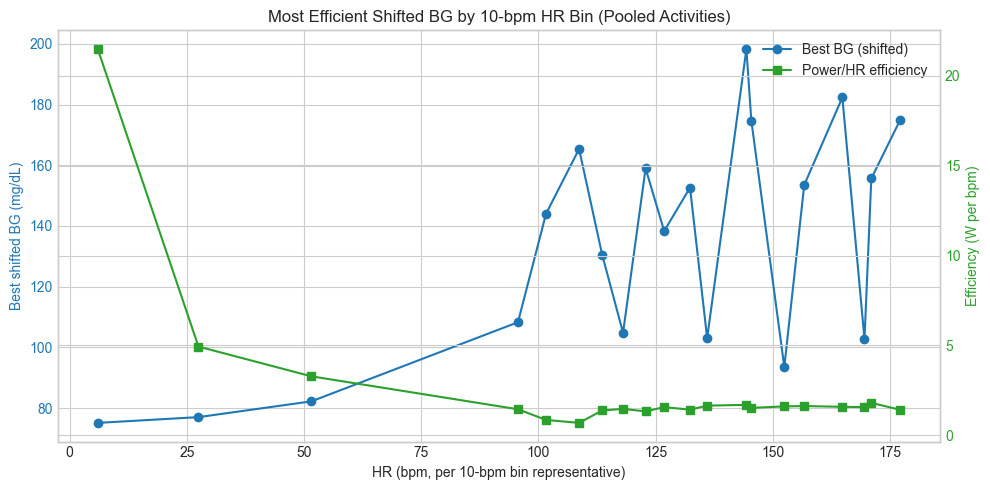

In [28]:
if 'best_bg_by_bin' in globals() and isinstance(best_bg_by_bin, pd.DataFrame) and not best_bg_by_bin.empty:
    plot_best_bg_by_hr_bin(best_bg_by_bin, title_suffix=source_label)
else:
    print('Best-BG efficiency plot skipped.')
